<a href="https://colab.research.google.com/github/lawho13/ML_Pricing/blob/main/src/tree_model_backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# from google.colab import drive
# drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.dates as mdates

path = "/common/home/lh811/Documents/cleaned.csv"

In [2]:
def load(path):
  # load csv into a pd dataframe; cast values to np.float32's for memory purposes; turn values in date to proper datetime objects; sort rows by permno, and inside permno groups, date
  df = pd.read_csv(path, dtype={col: np.float32 for col in pd.read_csv(path, nrows=0).columns if col not in ['DATE', 'year_month', 'permno']})
  df['DATE'] = pd.to_datetime(df['DATE'])
  df['year_month'] = pd.to_datetime(df['year_month']).dt.to_period('M')
  df = df.sort_values(['permno', 'DATE']).reset_index(drop=True)

  print(f"Memory: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")
  print(f"Loaded {df.shape[0]} rows and {df.shape[1]} columns")

  return df


In [3]:
clean = load(path)

Memory: 1.25 GB
Loaded 3016262 rows and 101 columns


In [4]:
def get_features_and_target(df, target_col='monthly_excess_ret'):
  drop_cols = ['DATE', 'year_month', 'permno', 'monthly_ret_raw', 'RF', target_col]
  feature_cols = [c for c in df.columns if c not in drop_cols]
  temp_df = df.dropna(subset=feature_cols + [target_col])

  X = temp_df[feature_cols].values
  y = temp_df[target_col].values

  return X, y, temp_df


def split_paper(df, initial_train_years=18, 
                val_years=12, test_years=1, date_col="DATE"):
    
    df = df.sort_values(date_col).reset_index(drop=True)

    start_date = df[date_col].min()
    end_date   = df[date_col].max()

    train_end = start_date + pd.DateOffset(years=initial_train_years)

    while True:

        val_start = train_end
        val_end   = val_start + pd.DateOffset(years=val_years)

        test_start = val_end
        test_end   = test_start + pd.DateOffset(years=test_years)

        if test_end > end_date:
            break

        train_df = df[df[date_col] < train_end]

        val_df = df[
            (df[date_col] >= val_start) &
            (df[date_col] <  val_end)
        ]

        test_df = df[
            (df[date_col] >= test_start) &
            (df[date_col] <  test_end)
        ]

        print(
            f"Train: {train_df[date_col].min().date()} → "
            f"{train_df[date_col].max().date()} | "
            f"Val: {val_df[date_col].min().date()} → "
            f"{val_df[date_col].max().date()} | "
            f"Test: {test_df[date_col].min().date()} → "
            f"{test_df[date_col].max().date()}"
        )

        yield train_df, val_df, test_df

        # move forward ONE year only
        train_end = train_end + pd.DateOffset(years=1)

def r2(y_test, y_pred):
    num = np.sum((y_test - y_pred)**2)
    den = np.sum(y_test**2)
    r2 = 100*(1 - (num/den))
    return r2

In [ ]:
def random_forest():
    rf_predictions = []
    rf_oos_results = []

    # param grids
    max_depth_grid = [1, 2, 3, 4, 5, 6]
    n_features = [3, 'sqrt', 30, 50, 80]

    for train, val, test in split_paper(clean):
        best_mse = float('inf')
        best_params = None
        best_r2 = None

        X_train, y_train, _ = get_features_and_target(train)
        X_val, y_val, _     = get_features_and_target(val)
        X_test, y_test, test_df = get_features_and_target(test)

        # =================================================================
        # tune depth and n_features
        # =================================================================
        for d in max_depth_grid:
            for f in n_features:
                model = RandomForestRegressor(
                    n_estimators=300,
                    max_features=f, 
                    max_depth=d,
                    n_jobs=-1,
                    min_samples_leaf=3000,
                    bootstrap=True,
                    random_state=13
                )

                model.fit(X_train, y_train)
                y_val_pred = model.predict(X_val)

                r2_val = r2(y_val, y_val_pred)
                mse_val = mean_squared_error(y_val, y_val_pred)

                if mse_val < best_mse:
                    best_mse = mse_val
                    best_r2 = r2_val
                    best_params = {
                        'n_estimators': 300,
                        'max_features': f,
                        'max_depth': d,
                    }

                    best_rf_model_obj = model

        # =================================================================
        # model evaluation 
        # =================================================================
        
        y_test_pred = best_rf_model_obj.predict(X_test)
        r2_test = r2(y_test, y_test_pred)
        mse_test = mean_squared_error(y_test, y_test_pred)

        rf_predictions.append(
            pd.DataFrame({
                'permno': test_df['permno'].values,
                'DATE': test_df['DATE'].values,
                'true': y_test,
                'rf': y_test_pred,
            })
        )

        rf_oos_results.append({
            'val_start': val['DATE'].min().date(),
            'val_end': val['DATE'].max().date(),
            'test_start': test['DATE'].min().date(),
            'test_end': test['DATE'].max().date(),
            'best_params': best_params,
            'r2_val': best_r2,
            'mse_val': best_mse,
            'mse_test': mse_test,
            'r2_test': r2_test
        })

    rf_predictions_df = pd.concat(rf_predictions, ignore_index=True)
    rf_predictions_df.to_csv(
        '/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/rf_predictions.csv',
        index=False
    )
    
    return rf_oos_results

In [6]:
rf_oos_results = random_forest()

Train: 1985-01-31 → 2002-12-31 | Val: 2003-01-31 → 2015-01-30 | Test: 2015-02-27 → 2016-01-29
Train: 1985-01-31 → 2004-01-30 | Val: 2004-02-27 → 2016-01-29 | Test: 2016-02-29 → 2016-12-30
Train: 1985-01-31 → 2004-12-31 | Val: 2005-01-31 → 2016-12-30 | Test: 2017-01-31 → 2017-12-29
Train: 1985-01-31 → 2005-12-30 | Val: 2006-01-31 → 2017-12-29 | Test: 2018-01-31 → 2018-12-31
Train: 1985-01-31 → 2006-12-29 | Val: 2007-01-31 → 2018-12-31 | Test: 2019-01-31 → 2019-12-31
Train: 1985-01-31 → 2007-12-31 | Val: 2008-01-31 → 2019-12-31 | Test: 2020-01-31 → 2021-01-29


In [7]:
rf_oos_results

[{'val_start': datetime.date(2003, 1, 31),
  'val_end': datetime.date(2015, 1, 30),
  'test_start': datetime.date(2015, 2, 27),
  'test_end': datetime.date(2016, 1, 29),
  'best_params': {'n_estimators': 300, 'max_features': 3, 'max_depth': 1},
  'r2_val': np.float64(0.2773356067442667),
  'mse_val': 0.017348185660797825,
  'mse_test': 0.014855137931171774,
  'r2_test': np.float64(-0.5851382093200241)},
 {'val_start': datetime.date(2004, 2, 27),
  'val_end': datetime.date(2016, 1, 29),
  'test_start': datetime.date(2016, 2, 29),
  'test_end': datetime.date(2016, 12, 30),
  'best_params': {'n_estimators': 300, 'max_features': 3, 'max_depth': 2},
  'r2_val': np.float64(0.0731171699154709),
  'mse_val': 0.016527558917568855,
  'mse_test': 0.015449169125226436,
  'r2_test': np.float64(1.4215557369285037)},
 {'val_start': datetime.date(2005, 1, 31),
  'val_end': datetime.date(2016, 12, 30),
  'test_start': datetime.date(2017, 1, 31),
  'test_end': datetime.date(2017, 12, 29),
  'best_params

In [8]:
def huber_loss(y_true, y_pred, delta):
  error = y_true - y_pred
  loss = np.where(
      np.abs(error) <= delta,
      error**2,
      2*np.abs(error)*delta - delta**2
  )
  return np.mean(loss)

In [ ]:
def gradient_boosted_tree():

    tree_predictions = []
    gradient_boosted_oos_results = []
    gradient_boosted_h_oos_results = []

    max_depth_grid = [1, 2]
    learning_rate_grid = [0.01, 0.1]
    
    # step by 10 to perfectly scan 1-1000 efficiently. 
    tree_tuning_range = range(1, 1001, 10)

    for train, val, test in split_paper(clean):

        best_mse = np.inf
        best_learning_rate = None
        best_iter_mse = 1000
        best_mse_depth = None
        best_model_mse_obj = None

        best_huber = np.inf
        best_learning_rate_huber = None
        best_iter_huber = 1000
        best_huber_depth = None
        best_model_huber_obj = None

        X_train, y_train, _ = get_features_and_target(train)
        X_val, y_val, _ = get_features_and_target(val)
        X_test, y_test, test_df = get_features_and_target(test)

        # proxy the residual for delta computation
        delta = np.quantile(np.abs(y_train - np.median(y_train)), 0.999)

        # Hyperparameter search & model training combined
        for d in max_depth_grid:
            for l in learning_rate_grid:

                # =========================================================
                # mse boosted tree
                # =========================================================
                model_mse = XGBRegressor(
                    max_depth=d,
                    n_estimators=1000,
                    learning_rate=l,
                    objective='reg:squarederror',
                    random_state=13,
                    n_jobs=-1
                )

                # Train fully to 1000 trees on training data only
                model_mse.fit(X_train, y_train, verbose=False)

                # Replicate the paper's tuning by evaluating every tree size on validation data
                for n_trees in tree_tuning_range:
                    val_pred = model_mse.predict(X_val, iteration_range=(0, n_trees))
                    mse_val = mean_squared_error(y_val, val_pred)

                    if mse_val < best_mse:
                        best_mse = mse_val
                        best_learning_rate = l
                        best_iter_mse = n_trees
                        best_mse_depth = d
                        best_model_mse_obj = model_mse 

                # =========================================================
                # "huber loss optimized" boosted regression tree
                # =========================================================
                model_h = XGBRegressor(
                    max_depth=d, 
                    n_estimators=1000,
                    learning_rate=l,
                    objective='reg:pseudohubererror',
                    huber_slope=delta,
                    random_state=13,
                    n_jobs=-1
                )

                # Train fully to 1000 trees on training data only
                model_h.fit(X_train, y_train, verbose=False)

                # Evaluate historical tree performance metrics sequentially
                for n_trees in tree_tuning_range:
                    val_pred_h = model_h.predict(X_val, iteration_range=(0, n_trees))
                    val_huber = huber_loss(y_val, val_pred_h, delta)

                    if val_huber < best_huber:
                        best_huber = val_huber
                        best_learning_rate_huber = l
                        best_iter_huber = n_trees
                        best_huber_depth = d
                        best_model_huber_obj = model_h

        # ---------------------------------------------------------
        # model eval
        # ---------------------------------------------------------
        
        # Enforce prediction using exactly the optimal tree slicing discovered in validation
        y_pred = best_model_mse_obj.predict(X_test, iteration_range=(0, best_iter_mse))
        r2_test = r2(y_test, y_pred)
        mse_test = mean_squared_error(y_test, y_pred)

        y_pred_h = best_model_huber_obj.predict(X_test, iteration_range=(0, best_iter_huber))
        r2_test_huber = r2(y_test, y_pred_h)
        mse_test_huber = mean_squared_error(y_test, y_pred_h)

        tree_predictions.append(
            pd.DataFrame({
                'permno': test_df['permno'].values,
                'DATE': test_df['DATE'].values,
                'true': y_test,
                'tree': y_pred,
                'treeh': y_pred_h
            })
        )

        gradient_boosted_oos_results.append({
            'test_start': test['DATE'].min().date(),
            'test_end': test['DATE'].max().date(),
            'best_learning_rate': best_learning_rate,
            'best_depth' : best_mse_depth,
            'mse_test': mse_test,
            'r2_test': r2_test,
            'best_iter' : best_iter_mse
        })

        gradient_boosted_h_oos_results.append({
            'test_start': test['DATE'].min().date(),
            'test_end': test['DATE'].max().date(),
            'best_learning_rate_huber': best_learning_rate_huber,
            'best_depth': best_huber_depth,
            'mse_test_huber': mse_test_huber,
            'r2_test_huber': r2_test_huber,
            'best_iter' : best_iter_huber
        })
        
        print(
            f"MSE: best_depth={best_mse_depth}, best_lr={best_learning_rate}, n_trees={best_iter_mse} | "
            f"Huber: best_depth={best_huber_depth}, best_lr={best_learning_rate_huber}, n_trees={best_iter_huber}"
        )

    tree_predictions_df = pd.concat(tree_predictions, ignore_index=True)

    tree_predictions_df.to_csv(
        '/common/home/lh811/Documents/ML_Pricing/data/aggregate_model_performance/tree_predictions.csv', index=False
    )

    return (
        gradient_boosted_oos_results,
        gradient_boosted_h_oos_results
    )

In [10]:
gradient_boosted_oos_results, gradient_boosted_h_oos_results = gradient_boosted_tree()

Train: 1985-01-31 → 2002-12-31 | Val: 2003-01-31 → 2015-01-30 | Test: 2015-02-27 → 2016-01-29
MSE: best_depth=2, best_lr=0.1, n_trees=41 | Huber: best_depth=2, best_lr=0.1, n_trees=41
Train: 1985-01-31 → 2004-01-30 | Val: 2004-02-27 → 2016-01-29 | Test: 2016-02-29 → 2016-12-30
MSE: best_depth=1, best_lr=0.01, n_trees=31 | Huber: best_depth=1, best_lr=0.01, n_trees=41
Train: 1985-01-31 → 2004-12-31 | Val: 2005-01-31 → 2016-12-30 | Test: 2017-01-31 → 2017-12-29
MSE: best_depth=1, best_lr=0.01, n_trees=161 | Huber: best_depth=1, best_lr=0.1, n_trees=21
Train: 1985-01-31 → 2005-12-30 | Val: 2006-01-31 → 2017-12-29 | Test: 2018-01-31 → 2018-12-31
MSE: best_depth=2, best_lr=0.01, n_trees=561 | Huber: best_depth=2, best_lr=0.1, n_trees=31
Train: 1985-01-31 → 2006-12-29 | Val: 2007-01-31 → 2018-12-31 | Test: 2019-01-31 → 2019-12-31
MSE: best_depth=2, best_lr=0.1, n_trees=71 | Huber: best_depth=2, best_lr=0.01, n_trees=551
Train: 1985-01-31 → 2007-12-31 | Val: 2008-01-31 → 2019-12-31 | Test: 20

In [11]:
gradient_boosted_h_oos_results

[{'test_start': datetime.date(2015, 2, 27),
  'test_end': datetime.date(2016, 1, 29),
  'best_learning_rate_huber': 0.1,
  'best_depth': 2,
  'mse_test_huber': 0.014685469679534435,
  'r2_test_huber': np.float32(0.563699),
  'best_iter': 41},
 {'test_start': datetime.date(2016, 2, 29),
  'test_end': datetime.date(2016, 12, 30),
  'best_learning_rate_huber': 0.01,
  'best_depth': 1,
  'mse_test_huber': 0.015513216145336628,
  'r2_test_huber': np.float32(1.0128796),
  'best_iter': 41},
 {'test_start': datetime.date(2017, 1, 31),
  'test_end': datetime.date(2017, 12, 29),
  'best_learning_rate_huber': 0.1,
  'best_depth': 1,
  'mse_test_huber': 0.011471358127892017,
  'r2_test_huber': np.float32(0.9373307),
  'best_iter': 21},
 {'test_start': datetime.date(2018, 1, 31),
  'test_end': datetime.date(2018, 12, 31),
  'best_learning_rate_huber': 0.1,
  'best_depth': 2,
  'mse_test_huber': 0.014394206926226616,
  'r2_test_huber': np.float32(-0.06406307),
  'best_iter': 31},
 {'test_start': dat

In [12]:
tree_performance = {
    'rf': rf_oos_results,
    'gradient_boosted': gradient_boosted_oos_results,
    'gradient_boosted_huber': gradient_boosted_h_oos_results
}


# ---------------------------------------------------
# Convert ALL to DataFrames safely
# ---------------------------------------------------

dfs = []

for name, res in tree_performance.items():

    df = pd.DataFrame(res)

    df['method'] = name.upper()

    dfs.append(df)

# ---------------------------------------------------
# Combine everything
# ---------------------------------------------------

all_models_mse = pd.concat(dfs, ignore_index=True)

# Ensure datetime
all_models_mse['test_start'] = pd.to_datetime(all_models_mse['test_start'])

display(all_models_mse.head())

,val_start,val_end,test_start,test_end,best_params,r2_val,mse_val,mse_test,r2_test,method,best_learning_rate,best_depth,best_iter,best_learning_rate_huber,mse_test_huber,r2_test_huber
0,2003-01-31,2015-01-30,2015-02-27,2016-01-29,"{'n_estimators': 300, 'max_features': 3, 'max_...",0.277336,0.017348,0.014855,-0.585138,RF,NaN,NaN,NaN,NaN,NaN,NaN
1,2004-02-27,2016-01-29,2016-02-29,2016-12-30,"{'n_estimators': 300, 'max_features': 3, 'max_...",0.073117,0.016528,0.015449,1.421556,RF,NaN,NaN,NaN,NaN,NaN,NaN
2,2005-01-31,2016-12-30,2017-01-31,2017-12-29,"{'n_estimators': 300, 'max_features': 3, 'max_...",0.289838,0.016722,0.011473,0.920930,RF,NaN,NaN,NaN,NaN,NaN,NaN
3,2006-01-31,2017-12-29,2018-01-31,2018-12-31,"{'n_estimators': 300, 'max_features': 'sqrt', ...",0.480906,0.016782,0.014483,-0.682966,RF,NaN,NaN,NaN,NaN,NaN,NaN
4,2007-01-31,2018-12-31,2019-01-31,2019-12-31,"{'n_estimators': 300, 'max_features': 'sqrt', ...",0.341341,0.017183,0.018163,0.508077,RF,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
all_models_mse[(all_models_mse['method']=='GRADIENT_BOOSTED') &
               (all_models_mse['method']=='GRADIENT_BOOSTED_H')]

,val_start,val_end,test_start,test_end,best_params,r2_val,mse_val,mse_test,r2_test,method,best_learning_rate,best_depth,best_iter,best_learning_rate_huber,mse_test_huber,r2_test_huber


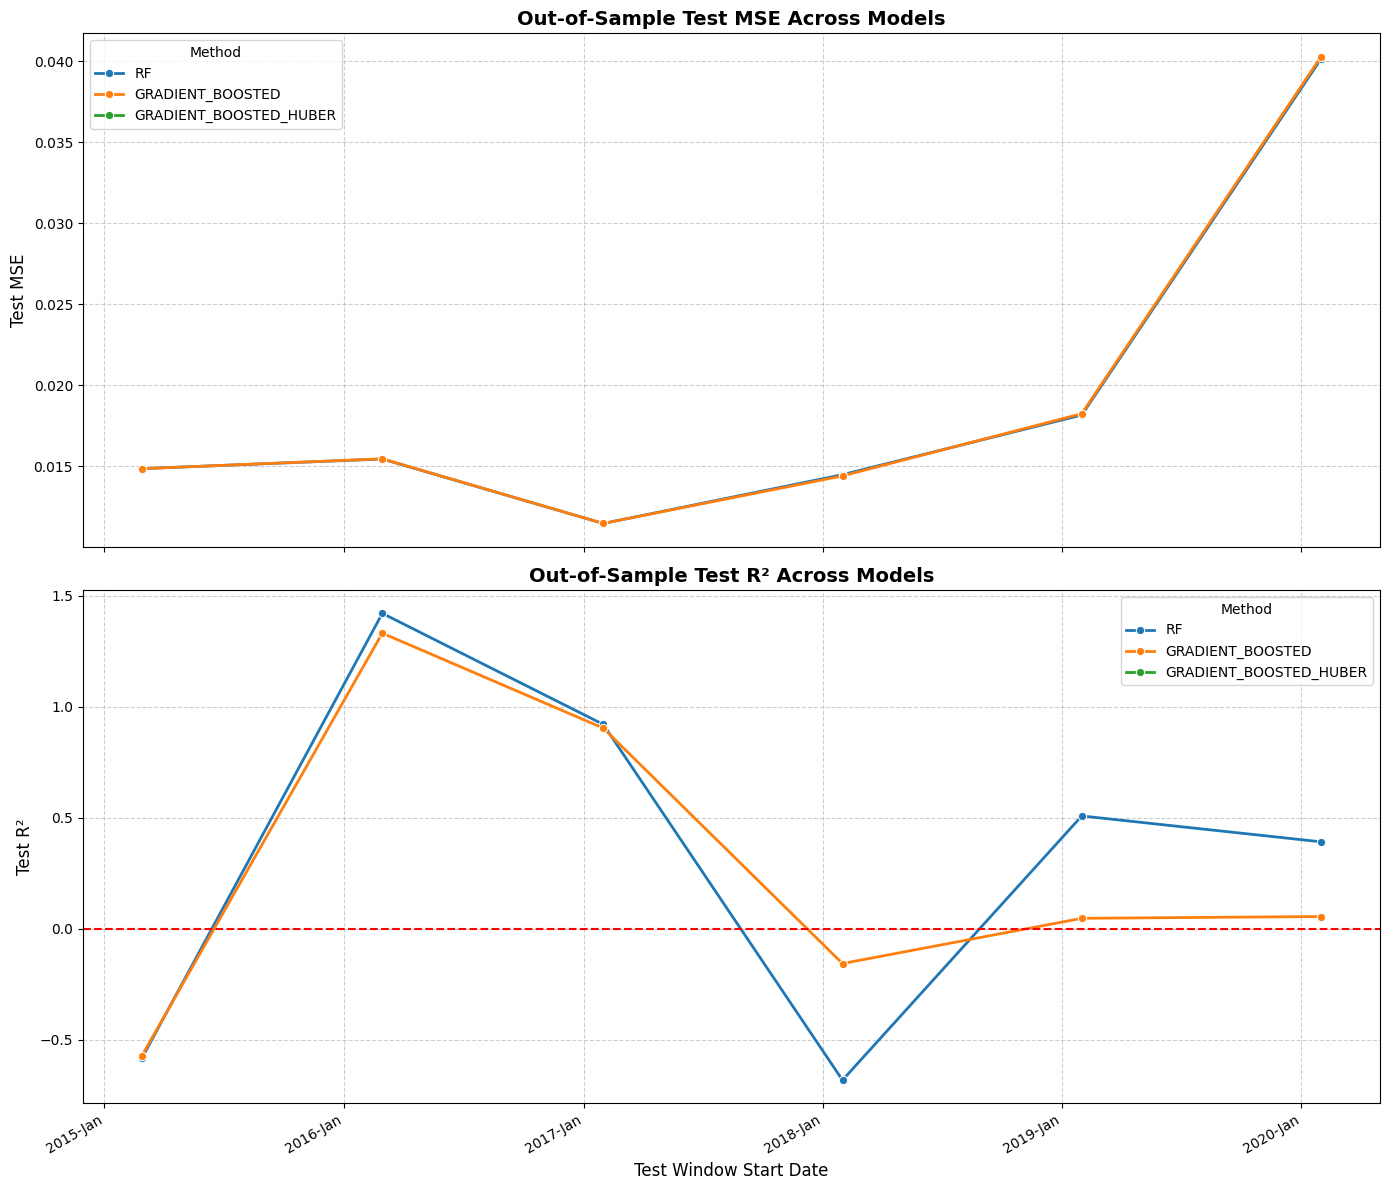

In [14]:
fig, axes = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(14, 12),
    sharex=True
)

# ---------------------------------------------------
# Plot TEST MSE
# ---------------------------------------------------

sns.lineplot(
    data=all_models_mse,
    x='test_start',
    y='mse_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[0]
)

axes[0].set_title(
    'Out-of-Sample Test MSE Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('Test MSE', fontsize=12)

axes[0].grid(True, linestyle='--', alpha=0.6)

axes[0].legend(title='Method')

# ---------------------------------------------------
# Plot TEST R²
# ---------------------------------------------------

sns.lineplot(
    data=all_models_mse,
    x='test_start',
    y='r2_test',
    hue='method',
    marker='o',
    linewidth=2,
    ax=axes[1]
)

axes[1].set_title(
    'Out-of-Sample Test R² Across Models',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_xlabel('Test Window Start Date', fontsize=12)

axes[1].set_ylabel('Test R²', fontsize=12)

axes[1].grid(True, linestyle='--', alpha=0.6)

# Reference line at R² = 0
axes[1].axhline(
    y=0,
    color='red',
    linestyle='--',
    linewidth=1.5
)

axes[1].legend(title='Method')

# ---------------------------------------------------
# Format dates
# ---------------------------------------------------

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%Y-%b')
)

fig.autofmt_xdate()

plt.tight_layout()

In [15]:
all_models_mse.to_csv("/common/home/lh811/Documents/ML_Pricing/data/individual_model_performance/tree_models.csv", index = False)